In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle 

from bioviper import selector 

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['font.sans-serif'] = 'Arial'
from matplotlib.colors import LogNorm


from studio_analysis_tools import *

with open("/Users/sam/Downloads/all_scores_Apr2026_v3.pkl", 'rb') as infile:
    all_scores = pickle.load(infile)
    
# Negate EVE scores so that higher is better for all methods
for prot,dataset in all_scores.items():
    if 'EVE' in dataset:
        dataset.loc[:,'EVE'] = -dataset['EVE']

# Add n_subs column to BLAT dataset        
all_scores['BLAT_ECOLX_Stiffler_2015']['n_subs'] = [mutant.count(',') + 1 if mutant!='WT' else 0 for mutant in all_scores['BLAT_ECOLX_Stiffler_2015'].index]


/Users/sam/miniforge3/envs/sequences/lib/python3.10/site-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


## Plotting enrichment curves

/Users/sam/Documents/GitHub/SpecificityStudio/Notebooks/studio_analysis_tools.py:487: RuntimeWarning: invalid value encountered in scalar divide
  curve = np.array([np.sum(X.iloc[:n].y) / (np.mean(X.y) * n) for n in n_vals])


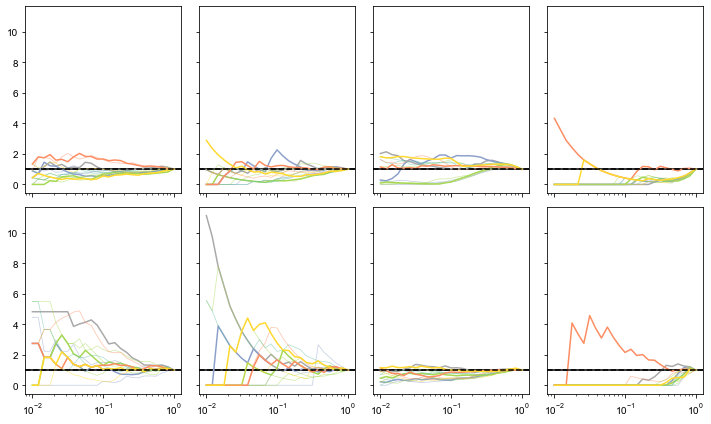

In [90]:
fig, axs = plt.subplots(2,4, figsize=(10,6), sharey=True, sharex=True)
axs = axs.flatten()


pdz_auc, pdz_l5 = EnrichmentAnalysis(all_scores, 'DLG4_HUMAN_Zarin_2024', models, ax=axs[0]);
blat_auc, blat_l5 = EnrichmentAnalysis(all_scores, 'BLAT_ECOLX_Stiffler_2015', models, ax=axs[1]);
amiE_auc, amiE_l5 = EnrichmentAnalysis(all_scores, 'AMIE_PSEAE_Wrenbeck_2017', models, ax=axs[2]);
pafa_auc, pafa_l5 = EnrichmentAnalysis(all_scores, 'ALPH_ELIME_Markin_2021', models, ax=axs[3]);
ramR_auc, ramR_l5 = EnrichmentAnalysis(all_scores, 'HTHTR_SALTY_dOelsnitz_2025', models, ax=axs[5]);
pho4_auc, pho4_l5 = EnrichmentAnalysis(all_scores, 'PHO4_YEAST_Aditham_2021', models, ax=axs[4]);
norA_auc, norA_l5 = EnrichmentAnalysis(all_scores, 'NORA_STAAU_Miller_2025', models, ax=axs[6]);
nramp_auc, nramp_l5 = EnrichmentAnalysis(all_scores, 'MNTH_DEIRA_Berry_2025', models, ax=axs[7]);

plt.tight_layout()

all_aucs = pd.concat([df for df in [pdz_auc, blat_auc, amiE_auc, pafa_auc, pho4_auc, ramR_auc, norA_auc, nramp_auc]], axis=1)
all_aucs['mean'] = all_aucs.mean(axis=1)
all_l5s = pd.concat([df for df in [pdz_l5, blat_l5, amiE_l5, pafa_l5, pho4_l5, ramR_l5, norA_l5, nramp_l5]], axis=1)
all_l5s['mean'] = all_l5s.mean(axis=1)

all_aucs.columns = ['pdz', 'amiE', 'blat', 'pafa', 'pho4', 'ramR', 'norA', 'nramp', 'mean']
all_l5s.columns = ['pdz', 'amiE', 'blat', 'pafa', 'pho4', 'ramR', 'norA', 'nramp', 'mean']

plt.savefig("/Users/sam/Dropbox (Harvard University)/SpecificityStudio/Figures/all_design_enrichment_curves.pdf", bbox_inches='tight')

In [94]:
all_scores['AMIE_PSEAE_Wrenbeck_2017']['isobutyramide_fitness'].max()

0.8438

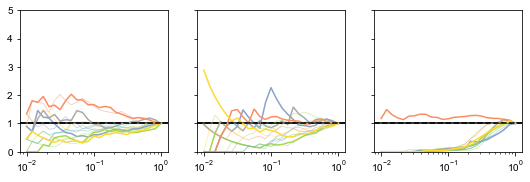

In [3]:
fig, axs = plt.subplots(1,3, figsize=(9,2.6), sharey=True, sharex=True)
axs = axs.flatten()

all_scores['BLAT_ECOLX_Stiffler_2015']['n_subs'] = [mutant.count(',') + 1 if mutant!='WT' else 0 for mutant in all_scores['BLAT_ECOLX_Stiffler_2015'].index]

pdz_auc, pdz_l5 = EnrichmentAnalysis(all_scores, 'DLG4_HUMAN_Zarin_2024', models, ax=axs[0]);
blat_auc, blat_l5 = EnrichmentAnalysis(all_scores, 'BLAT_ECOLX_Stiffler_2015', models, ax=axs[1])
nramp_auc, nramp_l5 = EnrichmentAnalysis(all_scores, 'MNTH_DEIRA_Berry_2025', models, ax=axs[2], filter_to_singles=False, filter_to_doubles=True)

for ax in axs:
    ax.set_ylim(0,5)

#plt.savefig("/Users/sam/Dropbox (Harvard University)/SpecificityStudio/Figures/Fig3_design_enrichment_curves_v2.pdf", bbox_inches='tight')

Text(56.0, 0.5, 'AUC')

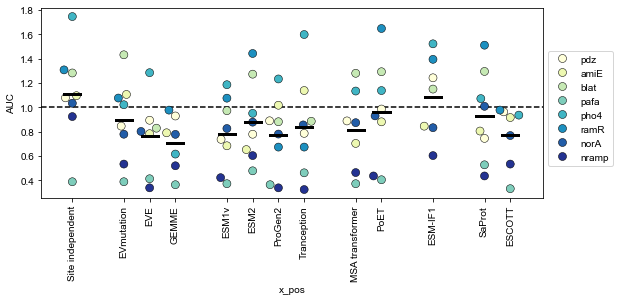

In [5]:
plt.figure(figsize=(9,3.5))
plt.axhline(1, c='k', ls='dashed')

data = all_aucs.sort_values('mean', ascending=False).T
data['protein'] = data.index.copy()

data_long = data.melt(id_vars='protein', value_vars = [i for i in model_names if i!='ProteinMPNN'], var_name='model', value_name='AUC')
data_long = data_long.loc[data_long['protein']!='mean']

model_classification_filt = {m:cat for m,cat in model_classification.items() if m in model_names and m!='ProteinMPNN'}
pos_dict = get_custom_coords(model_classification_filt, intra_gap=0.4, inter_gap=0.8)
data_long['x_pos'] = data_long['model'].map(pos_dict)

sns.swarmplot(data=data_long, hue='protein', y='AUC', x='x_pos', palette=map_cmap_to_proteins(protein_color_map, cm.YlGnBu), edgecolor='k', linewidth=0.5, s=8, native_scale=True)
plt.legend(loc='upper left', bbox_to_anchor=(1, 0.8))

mean_line_width = 0.25

data = all_aucs.loc[[i for i in model_names if i!='ProteinMPNN']].T
for model,x_pos in pos_dict.items():
    i = data.columns.get_loc(model)
    plt.plot([x_pos-mean_line_width/2, x_pos+mean_line_width/2], [data.iloc[-1,i], data.iloc[-1,i]], c='k', lw=3, zorder=10)

plt.xticks(list(pos_dict.values()), ['Site independent', 'EVmutation', 'EVE', 'GEMME', 'ESM1v', 'ESM2', 'ProGen2', 'Tranception', 'MSA transformer', 'PoET', 'ESM-IF1', 'SaProt', 'ESCOTT'], rotation=90)
plt.ylabel("AUC")

Text(64.375, 0.5, 'L5 score')

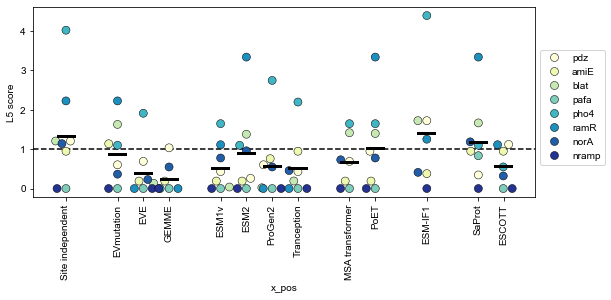

In [6]:
plt.figure(figsize=(9,3.5))
plt.axhline(1, c='k', ls='dashed')

data = all_l5s.sort_values('mean', ascending=False).T
data['protein'] = data.index.copy()

data_long = data.melt(id_vars='protein', value_vars = [i for i in model_names if i!='ProteinMPNN'], var_name='model', value_name='AUC')
data_long = data_long.loc[data_long['protein']!='mean']

model_classification_filt = {m:cat for m,cat in model_classification.items() if m in model_names and m!='ProteinMPNN'}
pos_dict = get_custom_coords(model_classification_filt, intra_gap=0.4, inter_gap=0.8)
data_long['x_pos'] = data_long['model'].map(pos_dict)

sns.swarmplot(data=data_long, hue='protein', y='AUC', x='x_pos', palette=map_cmap_to_proteins(protein_color_map, cm.YlGnBu), edgecolor='k', linewidth=0.5, s=8, native_scale=True)
plt.legend(loc='upper left', bbox_to_anchor=(1, 0.8))

mean_line_width = 0.25

data = all_l5s.loc[[i for i in model_names if i!='ProteinMPNN']].T
for model,x_pos in pos_dict.items():
    i = data.columns.get_loc(model)
    plt.plot([x_pos-mean_line_width/2, x_pos+mean_line_width/2], [data.iloc[-1,i], data.iloc[-1,i]], c='k', lw=3, zorder=10)

plt.xticks(list(pos_dict.values()), ['Site independent', 'EVmutation', 'EVE', 'GEMME', 'ESM1v', 'ESM2', 'ProGen2', 'Tranception', 'MSA transformer', 'PoET', 'ESM-IF1', 'SaProt', 'ESCOTT'], rotation=90)
plt.ylabel("L5 score")

#plt.savefig("/Users/sam/Dropbox (Harvard University)/SpecificityStudio/Figures/Figure 3/design_l5_comparison.pdf", bbox_inches='tight')

## Figure 4: Fitting weighted ensembles

First with all datasets:

Error occurred while processing MSA_Transformer: "['MSA_Transformer'] not in index"
Error occurred while processing ESM-IF1: ufunc 'expit' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''


/Users/sam/Documents/GitHub/SpecificityStudio/Notebooks/studio_analysis_tools.py:302: RuntimeWarning: invalid value encountered in scalar divide
  total_loss += nll / np.sum(weights)
/Users/sam/Documents/GitHub/SpecificityStudio/Notebooks/studio_analysis_tools.py:302: RuntimeWarning: invalid value encountered in scalar divide
  total_loss += nll / np.sum(weights)
/Users/sam/Documents/GitHub/SpecificityStudio/Notebooks/studio_analysis_tools.py:302: RuntimeWarning: invalid value encountered in scalar divide
  total_loss += nll / np.sum(weights)


Error occurred while processing ESM-IF1: ufunc 'expit' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''


/Users/sam/Documents/GitHub/SpecificityStudio/Notebooks/studio_analysis_tools.py:302: RuntimeWarning: invalid value encountered in scalar divide
  total_loss += nll / np.sum(weights)
/Users/sam/Documents/GitHub/SpecificityStudio/Notebooks/studio_analysis_tools.py:302: RuntimeWarning: invalid value encountered in scalar divide
  total_loss += nll / np.sum(weights)
/Users/sam/Documents/GitHub/SpecificityStudio/Notebooks/studio_analysis_tools.py:302: RuntimeWarning: invalid value encountered in scalar divide
  total_loss += nll / np.sum(weights)
/Users/sam/Documents/GitHub/SpecificityStudio/Notebooks/studio_analysis_tools.py:487: RuntimeWarning: invalid value encountered in scalar divide
  curve = np.array([np.sum(X.iloc[:n].y) / (np.mean(X.y) * n) for n in n_vals])
/Users/sam/Documents/GitHub/SpecificityStudio/Notebooks/studio_analysis_tools.py:487: RuntimeWarning: invalid value encountered in scalar divide
  curve = np.array([np.sum(X.iloc[:n].y) / (np.mean(X.y) * n) for n in n_vals])


Error occurred while processing MSA_Transformer: "['MSA_Transformer'] not in index"
Error occurred while processing ESM-IF1: ufunc 'expit' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''


...

/Users/sam/Documents/GitHub/SpecificityStudio/Notebooks/studio_analysis_tools.py:302: RuntimeWarning: invalid value encountered in scalar divide
  total_loss += nll / np.sum(weights)
/Users/sam/Documents/GitHub/SpecificityStudio/Notebooks/studio_analysis_tools.py:302: RuntimeWarning: invalid value encountered in scalar divide
  total_loss += nll / np.sum(weights)
/Users/sam/Documents/GitHub/SpecificityStudio/Notebooks/studio_analysis_tools.py:302: RuntimeWarning: invalid value encountered in scalar divide
  total_loss += nll / np.sum(weights)


Error occurred while processing MSA_Transformer: "['MSA_Transformer'] not in index"
Error occurred while processing ESM-IF1: ufunc 'expit' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''
Error occurred while processing MSA_Transformer: "['MSA_Transformer'] not in index"
Error occurred while processing ESM-IF1: ufunc 'expit' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''


/Users/sam/Documents/GitHub/SpecificityStudio/Notebooks/studio_analysis_tools.py:302: RuntimeWarning: invalid value encountered in scalar divide
  total_loss += nll / np.sum(weights)
/Users/sam/Documents/GitHub/SpecificityStudio/Notebooks/studio_analysis_tools.py:302: RuntimeWarning: invalid value encountered in scalar divide
  total_loss += nll / np.sum(weights)


Error occurred while processing MSA_Transformer: "['MSA_Transformer'] not in index"


/Users/sam/Documents/GitHub/SpecificityStudio/Notebooks/studio_analysis_tools.py:302: RuntimeWarning: invalid value encountered in scalar divide
  total_loss += nll / np.sum(weights)
/Users/sam/Documents/GitHub/SpecificityStudio/Notebooks/studio_analysis_tools.py:302: RuntimeWarning: invalid value encountered in scalar divide
  total_loss += nll / np.sum(weights)
/Users/sam/Documents/GitHub/SpecificityStudio/Notebooks/studio_analysis_tools.py:302: RuntimeWarning: invalid value encountered in scalar divide
  total_loss += nll / np.sum(weights)


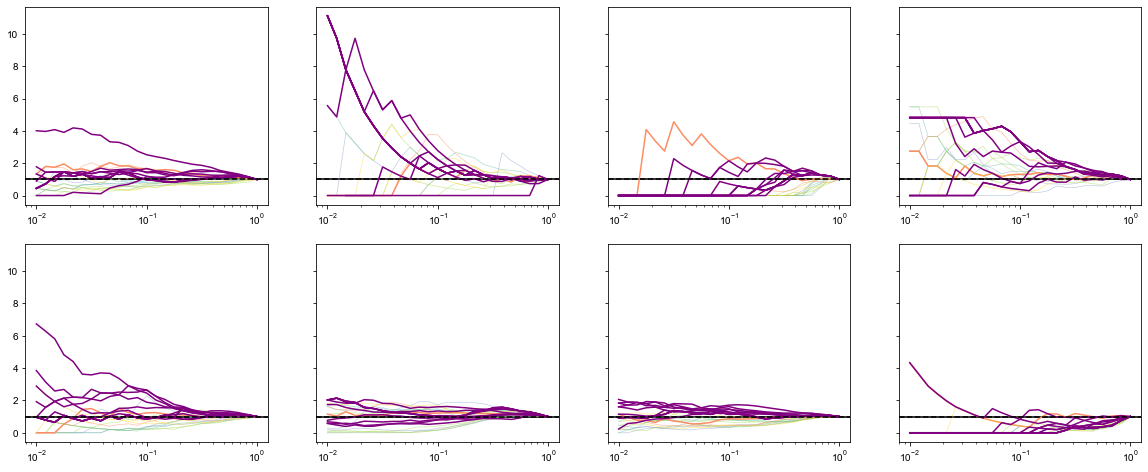

In [35]:
fig, axs = plt.subplots(2,4, figsize=(20,8), sharey=True)
axs = axs.flatten()
#weighted_ensemble_list = [f'weighted_ensemble:Site_independent+{alpha_dict[model]:.4f}*{model}' for model in alpha_dict]

all_aucs = []
all_l5s = []
all_alpha_dicts = {}

DMS_category_1 = ['DLG4_HUMAN_Zarin_2024', 'HTHTR_SALTY_dOelsnitz_2025', 'MNTH_DEIRA_Berry_2025', 'PHO4_YEAST_Aditham_2021', 'BLAT_ECOLX_Stiffler_2015']
DMS_category_2 = ['AMIE_PSEAE_Wrenbeck_2017', 'NORA_STAAU_Miller_2025', 'ALPH_ELIME_Markin_2021']

for n, DMS_id in enumerate(DMS_category_1 + DMS_category_2):
    
    alpha_dict = {}
    for model_2 in list(models)[1:]:
        try:
            alpha = fit_weighted_ensemble(all_scores, 'Site_independent', model_2, [prot for prot in DMS_category_1 + DMS_category_2 if prot!=DMS_id])
            alpha_dict[model_2] = alpha
        except Exception as e:
            print(f"Error occurred while processing {model_2}: {e}")
            
    all_alpha_dicts[DMS_id] = alpha_dict
            
    weighted_ensemble_list = [f'weighted_ensemble:Site_independent+{alpha_dict[model]:.4f}*{model}' for model in alpha_dict]

    auc_list, l5_list = EnrichmentAnalysis(all_scores, DMS_id, ax=axs[n], plot_perfect=False, model_list=list(models) + weighted_ensemble_list,
                    highlight_models=['ProteinMPNN'])
    all_aucs.append(auc_list)
    all_l5s.append(l5_list)
    
all_aucs = pd.concat(all_aucs, axis=1)
all_l5s = pd.concat(all_l5s, axis=1)

all_aucs['mean_AUC'] = all_aucs.mean(axis=1)
all_l5s['mean_L5'] = all_l5s.mean(axis=1)

Error occurred while processing MSA_Transformer: "['MSA_Transformer'] not in index"


/Users/sam/Documents/GitHub/SpecificityStudio/Notebooks/studio_analysis_tools.py:487: RuntimeWarning: invalid value encountered in scalar divide
  curve = np.array([np.sum(X.iloc[:n].y) / (np.mean(X.y) * n) for n in n_vals])
/Users/sam/Documents/GitHub/SpecificityStudio/Notebooks/studio_analysis_tools.py:487: RuntimeWarning: invalid value encountered in scalar divide
  curve = np.array([np.sum(X.iloc[:n].y) / (np.mean(X.y) * n) for n in n_vals])


Error occurred while processing MSA_Transformer: "['MSA_Transformer'] not in index"
Error occurred while processing MSA_Transformer: "['MSA_Transformer'] not in index"
Error occurred while processing MSA_Transformer: "['MSA_Transformer'] not in index"


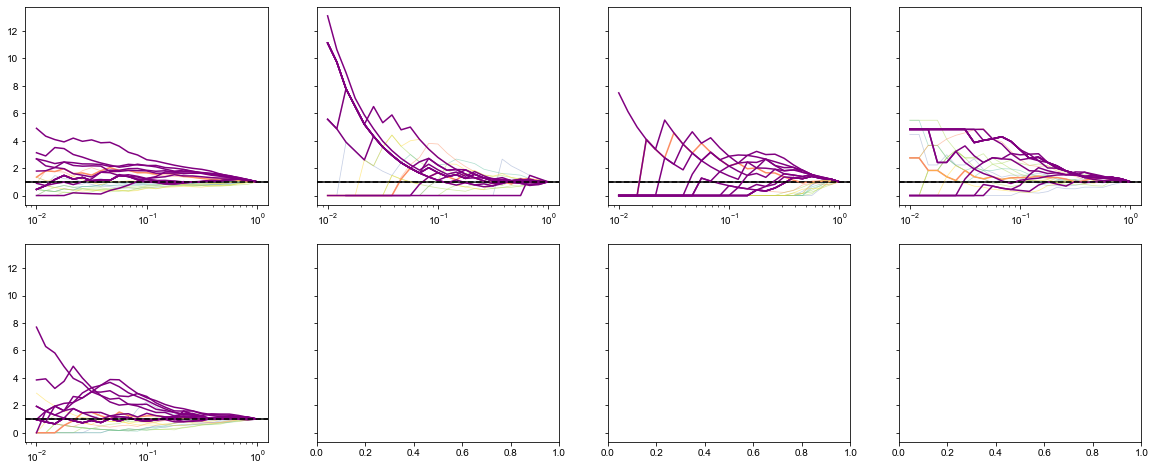

In [42]:
fig, axs = plt.subplots(2,4, figsize=(20,8), sharey=True)
axs = axs.flatten()
#weighted_ensemble_list = [f'weighted_ensemble:Site_independent+{alpha_dict[model]:.4f}*{model}' for model in alpha_dict]

class_1_l5s = []
class_1_aucs = []
class_1_alpha_dicts = {}

DMS_category_1 = ['DLG4_HUMAN_Zarin_2024', 'HTHTR_SALTY_dOelsnitz_2025', 'MNTH_DEIRA_Berry_2025', 'PHO4_YEAST_Aditham_2021', 'BLAT_ECOLX_Stiffler_2015']
DMS_category_2 = ['AMIE_PSEAE_Wrenbeck_2017', 'NORA_STAAU_Miller_2025', 'ALPH_ELIME_Markin_2021']

for n, DMS_id in enumerate(DMS_category_1):
    
    alpha_dict = {}
    for model_2 in list(models)[1:]:
        try:
            alpha = fit_weighted_ensemble(all_scores, 'Site_independent', model_2, [prot for prot in DMS_category_1 if prot!=DMS_id])
            alpha_dict[model_2] = alpha
        except Exception as e:
            print(f"Error occurred while processing {model_2}: {e}")
            
    class_1_alpha_dicts[DMS_id] = alpha_dict
            
    weighted_ensemble_list = [f'weighted_ensemble:Site_independent+{alpha_dict[model]:.4f}*{model}' for model in alpha_dict]

    auc_list, l5_list = EnrichmentAnalysis(all_scores, DMS_id, ax=axs[n], plot_perfect=False, model_list=list(models) + weighted_ensemble_list,
                    highlight_models=['ProteinMPNN'])
    
    class_1_aucs.append(auc_list)
    class_1_l5s.append(l5_list)
    
class_1_aucs = pd.concat(class_1_aucs, axis=1)
class_1_l5s = pd.concat(class_1_l5s, axis=1)

class_1_aucs['mean_AUC'] = class_1_aucs.mean(axis=1)
class_1_l5s['mean_L5'] = class_1_l5s.mean(axis=1)

In [47]:
from matplotlib import cm
def map_cmap_to_proteins(protein_list, cmap):
    n = len(protein_list)
    colors = [cmap(i/n) for i in range(n)]
    return {protein: colors[i] for i, protein in enumerate(protein_list)}

def StudioSwarmplot(dataset, model_classification_dict, cmap=cm.YlGnBu, value_name='value', mean_lw=0.25, dataset_list=None, intra_gap=0.4, inter_gap=0.8, ax=None, figsize=(6,5),
                    plot_legend=True):
    
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    
    data_c = dataset.copy()
    
    for row_name in ['mean_L5', 'model_2', 'mean_alpha']:
        if row_name in data_c.index:
            data_c.drop(row_name, axis=0, inplace=True)
            
            
    data_c['protein'] = [i.replace('L5_','') for i in data_c.index]

    data_long = data_c.melt(id_vars=['protein'], var_name='model', value_name=value_name)
    
    pos_dict = get_custom_coords(model_classification_dict, intra_gap=intra_gap, inter_gap=inter_gap)
    data_long['x_pos'] = data_long['model'].map(pos_dict)
        
    if dataset_list is None:
        dataset_list = data_c.index
        
    palette = map_cmap_to_proteins(dataset_list, cmap)
    
    sns.swarmplot(data=data_long, hue='protein', y=value_name, x='x_pos', palette=palette, edgecolor='k', linewidth=0.5, s=8, native_scale=True, ax=ax)
    if plot_legend:
        ax.legend(loc='upper left', bbox_to_anchor=(1, 0.8))
    else:
        ax.legend([],[], frameon=False)
           
    data_c.drop('protein', axis=1, inplace=True)
    
    dc_mean = data_c.mean(axis=0)
    
    for model,x_pos in pos_dict.items():
        i = data_c.columns.get_loc(model)
        ax.plot([x_pos-mean_lw/2, x_pos+mean_lw/2], [dc_mean[i], dc_mean[i]], c='k', lw=3, zorder=10)
        
    ax.set_xticks(list(pos_dict.values()), model_classification_dict.keys(), rotation=90)

In [30]:
# all_aucs['mean_AUC'] = all_aucs.mean(axis=1)
# all_l5s['mean_L5'] = all_l5s.mean(axis=1)

In [70]:
model_classification 

{'Site_independent': 'conservation',
 'EVmutation': 'alignment_covariation',
 'EVE': 'alignment_covariation',
 'GEMME': 'alignment_covariation',
 'ESM1v': 'plm',
 'ESM2': 'plm',
 'Progen2': 'plm',
 'Tranception_no_retrieval': 'plm',
 'MSA_Transformer': 'msa_plm',
 'PoET': 'msa_plm',
 'ProteinMPNN': 'inverse_folding',
 'ESM-IF1': 'inverse_folding',
 'SaProt_650M_AF2': 'structure_sequence',
 'ESCOTT': 'structure_sequence'}

In [82]:
alphas

,DLG4_HUMAN_Zarin_2024,HTHTR_SALTY_dOelsnitz_2025,MNTH_DEIRA_Berry_2025,PHO4_YEAST_Aditham_2021,BLAT_ECOLX_Stiffler_2015,AMIE_PSEAE_Wrenbeck_2017,NORA_STAAU_Miller_2025,ALPH_ELIME_Markin_2021
EVmutation,0.014011,-0.556918,0.129842,-0.776259,-0.555698,-0.570295,-0.160643,-0.686798
EVE,-0.556084,-0.611749,-0.203111,-1.066626,-0.585288,-1.182907,-0.562475,-0.667637
GEMME,-0.254151,-0.490414,-0.136692,-0.475688,-0.461854,-0.581850,-0.456694,-0.637212
ESM1v,-0.539513,-0.581441,-0.220990,-0.798210,-0.566795,-0.604584,-0.568310,-0.580842
ESM2,-0.176025,-0.286311,-0.147206,-0.393588,-0.229911,-0.343160,-0.270363,-0.389014
Progen2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Tranception_no_retrieval,0.000000,-0.000047,-0.000024,-0.007468,-0.006217,-0.005239,-0.005735,-0.012004
PoET,-0.041118,-0.042839,0.040691,-0.047632,-0.041198,-0.043498,-0.042204,-0.041574
ProteinMPNN,0.000038,0.002483,0.000040,0.000035,0.002585,0.000036,0.002707,0.003699
SaProt_650M_AF2,-0.305931,-0.375593,-0.045804,-0.612517,-0.364181,-0.418081,-0.380459,-0.484320


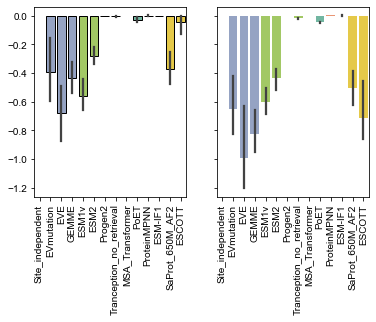

In [ ]:
alphas = pd.DataFrame(all_alpha_dicts).drop('MSA_Transformer')
model_colors = {model:color_key[model_classification[model]] for model in models}

fig, ax = plt.subplots(1,2,figsize=(6,3.5), sharey=True)
sns.barplot(alphas.T, ax=ax[0], palette=model_colors, order=model_names)
ax[0].set_xticks(range(len(model_names)), model_names, rotation=90)

class1_alphas = pd.DataFrame(class_1_alpha_dicts).drop('MSA_Transformer')

sns.barplot(class1_alphas.T, ax=ax[1], palette=model_colors, order=model_names)
ax[1].set_xticks(range(len(model_names)), model_names, rotation=90);

plt.savefig('alpha_barplots.pdf', bbox_inches='tight')

/var/folders/23/02r51lhs1890z43wddtd5qpw0000gr/T/ipykernel_91966/2965315393.py:44: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.plot([x_pos-mean_lw/2, x_pos+mean_lw/2], [dc_mean[i], dc_mean[i]], c='k', lw=3, zorder=10)
/var/folders/23/02r51lhs1890z43wddtd5qpw0000gr/T/ipykernel_91966/2965315393.py:44: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.plot([x_pos-mean_lw/2, x_pos+mean_lw/2], [dc_mean[i], dc_mean[i]], c='k', lw=3, zorder=10)


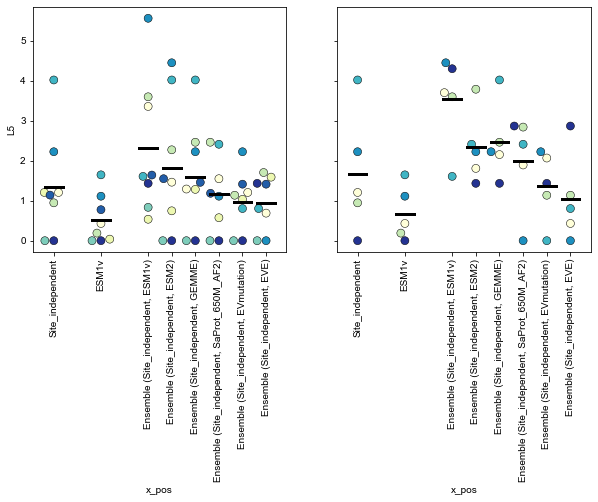

In [52]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4.5), sharey=True)

all_data = all_l5s.sort_values('mean_L5', ascending=False).T
class1_data = class_1_l5s.sort_values('mean_L5', ascending=False).T

model_classification_new = {'Site_independent': 'conservation', 'ESM1v': 'plm'}
dataset_list = ['DLG4_HUMAN_Zarin_2024', 'AMIE_PSEAE_Wrenbeck_2017', 'BLAT_ECOLX_Stiffler_2015', 'ALPH_ELIME_Markin_2021', 'PHO4_YEAST_Aditham_2021', 'HTHTR_SALTY_dOelsnitz_2025', 'NORA_STAAU_Miller_2025', 'MNTH_DEIRA_Berry_2025']

for model_2 in ['ESM1v', 'ESM2', 'GEMME', 'SaProt_650M_AF2', 'EVmutation', 'EVE']:
    model_classification_new[f'Ensemble (Site_independent, {model_2})'] = 'weighted_ensemble'

StudioSwarmplot(all_data, model_classification_new, value_name="L5", dataset_list=dataset_list, ax=ax[0], plot_legend=False, mean_lw=0.3)
StudioSwarmplot(class1_data, model_classification_new, value_name="L5", dataset_list=dataset_list, ax=ax[1], plot_legend=False, mean_lw=0.3)

plt.savefig("/Users/sam/Dropbox (Harvard University)/SpecificityStudio/Figures/Figure 3/design_l5_comparison_swarm.pdf", bbox_inches='tight')

In [56]:
class_1_alpha_dicts['DLG4_HUMAN_Zarin_2024']['ESM1v']

-0.6028271279212031

In [58]:
class_1_alpha_dicts

{'DLG4_HUMAN_Zarin_2024': {'EVmutation': -0.6968831246032062,
  'EVE': -1.2268901947453714,
  'GEMME': -1.0146101840571802,
  'ESM1v': -0.6028271279212031,
  'ESM2': -0.3811951577406364,
  'Progen2': 0.0,
  'Tranception_no_retrieval': -0.009897861080376288,
  'PoET': -0.04405536863924545,
  'ProteinMPNN': 0.0035957229661765784,
  'ESM-IF1': 0.0,
  'SaProt_650M_AF2': -0.49013938235122356,
  'ESCOTT': -0.8909025340036988},
 'HTHTR_SALTY_dOelsnitz_2025': {'EVmutation': -0.7059599255685407,
  'EVE': -1.1910133471091526,
  'GEMME': -0.8686221659381554,
  'ESM1v': -0.6143734032370562,
  'ESM2': -0.44728588299069455,
  'Progen2': 0.0,
  'Tranception_no_retrieval': -0.014389633096554728,
  'MSA_Transformer': -0.6082691247694636,
  'PoET': -0.04201682950940549,
  'ProteinMPNN': 0.004313329594525316,
  'ESM-IF1': -0.0033304721884399083,
  'SaProt_650M_AF2': -0.512790530569494,
  'ESCOTT': -0.8211592652058625},
 'MNTH_DEIRA_Berry_2025': {'EVmutation': -0.22724316084198964,
  'EVE': -0.28187325416

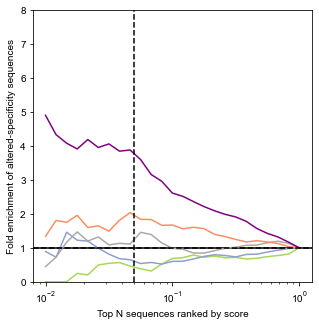

In [57]:
ena = EnrichmentAnalysis(all_scores, 'DLG4_HUMAN_Zarin_2024', ['ESM1v', 'EVmutation', 'Site_independent', 'ProteinMPNN', f'weighted_ensemble:Site_independent+{class_1_alpha_dicts["DLG4_HUMAN_Zarin_2024"]["ESM1v"]}*ESM1v']);
plt.ylim(0,8)
plt.ylabel(f"Fold enrichment of altered-specificity sequences")
plt.xlabel("Top N sequences ranked by score")
plt.axvline(0.05, c='k', ls='--')

In [155]:
model_classification_new = {'Site_independent': 'conservation', 'ESM1v': 'plm'}

for model_2 in ['ESM1v', 'ESM2', 'GEMME', 'SaProt_650M_AF2', 'EVE', 'EVmutation']:
    model_classification_new[f'Ensemble (Site_independent, {model_2})'] = 'weighted_ensemble'

pos_dict = get_custom_coords(model_classification_new, intra_gap=0.4, inter_gap=0.8)
data_long['x_pos'] = data_long['model'].map(pos_dict)

In [133]:
pos_dict

{'Site_independent': 0.0,
 'ESM1v': 0.8,
 'Ensemble (Site_independent, ESM1v)': 1.6,
 'Ensemble (Site_independent, ESM2)': 2.0,
 'Ensemble (Site_independent, GEMME)': 2.4,
 'Ensemble (Site_independent, SaProt_650M_AF2)': 2.8,
 'Ensemble (Site_independent, EVE)': 3.1999999999999997,
 'Ensemble (Site_independent, EVmutation)': 3.5999999999999996}

In [135]:
data_c.columns

Index(['Ensemble (Site_independent, ESM1v)',
       'Ensemble (Site_independent, ESM2)',
       'Ensemble (Site_independent, GEMME)', 'Site_independent',
       'Ensemble (Site_independent, SaProt_650M_AF2)',
       'Ensemble (Site_independent, EVmutation)',
       'Ensemble (Site_independent, EVE)', 'ESM1v', 'protein'],
      dtype='object', name='model')

/var/folders/23/02r51lhs1890z43wddtd5qpw0000gr/T/ipykernel_51221/77061757.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot([x_pos-mean_line_width/2, x_pos+mean_line_width/2], [dc_mean[i], dc_mean[i]], c='k', lw=3, zorder=10)


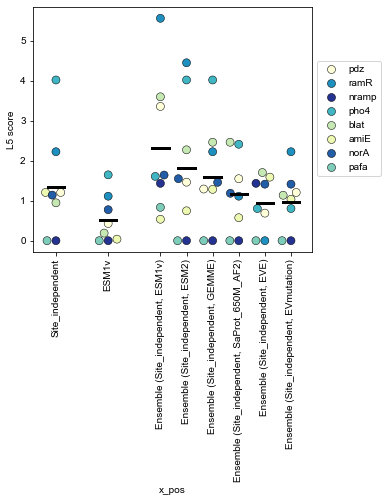

In [ ]:
plt.figure(figsize=(5.0, 4.5))

sns.swarmplot(data=data_long, hue='protein', y='L5_score', x='x_pos', palette=map_cmap_to_proteins(protein_color_map, cm.YlGnBu), edgecolor='k', linewidth=0.5, s=8, native_scale=True)
plt.legend(loc='upper left', bbox_to_anchor=(1, 0.8))

mean_line_width=0.25

dc_mean = pd.Series(data_c.values[:,:-2].mean(axis=0), index=data_c.columns[:-2])

for model,x_pos in pos_dict.items():
    i = data_c.columns.get_loc(model)
    plt.plot([x_pos-mean_line_width/2, x_pos+mean_line_width/2], [dc_mean[i], dc_mean[i]], c='k', lw=3, zorder=10)

plt.xticks(list(pos_dict.values()), order, rotation=90)
plt.ylabel("L5 score")

plt.savefig("/Users/sam/Dropbox (Harvard University)/SpecificityStudio/Figures/Figure 3/design_l5_comparison_v2.pdf", bbox_inches='tight')

In [217]:
protein_color_map = {
    'pdz': "#6baed6",
    'amiE': "#e6550d",
    'blat': "#fd8d3c",
    'pafa': "#fdd0a2",
    'pho4': "#31a354",
    'ramR': "#a1d99b",
    'norA': "#756bb1",
    'nramp': "#bcbddc"
}

dataset_list = ['DLG4_HUMAN_Zarin_2024', 'AMIE_PSEAE_Wrenbeck_2017', 'BLAT_ECOLX_Stiffler_2015', 'ALPH_ELIME_Markin_2021', 'PHO4_YEAST_Aditham_2021', 'HTHTR_SALTY_dOelsnitz_2025', 'NORA_STAAU_Miller_2025', 'MNTH_DEIRA_Berry_2025']

In [253]:
data

model,"Ensemble (Site_independent, ESM1v)","Ensemble (Site_independent, ESM2)","Ensemble (Site_independent, SaProt_650M_AF2)","Ensemble (Site_independent, GEMME)","Ensemble (Site_independent, EVmutation)","Ensemble (Site_independent, ESCOTT)","Ensemble (Site_independent, EVE)",Site_independent,ESM1v
L5_DLG4_HUMAN_Zarin_2024,3.95843,2.151321,1.979215,2.152535,2.583042,1.722028,0.430507,1.20542,0.430264
L5_HTHTR_SALTY_dOelsnitz_2025,4.447619,2.22381,0.0,2.22381,2.22381,2.22381,0.0,2.22381,1.111905
L5_MNTH_DEIRA_Berry_2025,5.732523,4.299392,5.732523,1.433131,1.433131,0.0,2.866261,0.0,0.0
L5_BLAT_ECOLX_Stiffler_2015,3.597143,3.97579,2.650527,2.461203,0.946617,2.27188,1.13594,0.946617,0.189323
mean_L5,4.433929,3.162578,2.590566,2.06767,1.79665,1.554429,1.108177,1.093961,0.432873
model_2,ESM1v,ESM2,SaProt_650M_AF2,GEMME,EVmutation,ESCOTT,EVE,NaN,NaN
mean_alpha,-0.715082,-0.586944,-0.692903,-0.881758,-0.867632,-0.782324,-0.956861,-1.0,-1.0


/var/folders/23/02r51lhs1890z43wddtd5qpw0000gr/T/ipykernel_51221/57994565.py:40: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.plot([x_pos-mean_line_width/2, x_pos+mean_line_width/2], [dc_mean[i], dc_mean[i]], c='k', lw=3, zorder=10)


<Figure size 360x324 with 0 Axes>

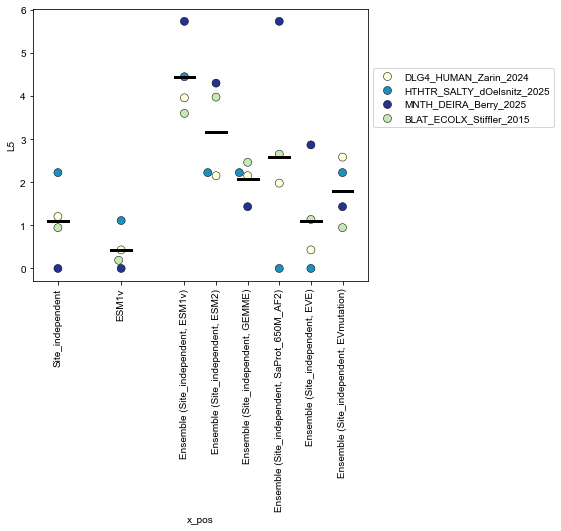

In [276]:
plt.figure(figsize=(5.0, 4.5))

StudioSwarmplot(data, model_classification_new, value_name="L5", dataset_list=dataset_list)

In [53]:
mean_alpha

NameError: name 'mean_alpha' is not defined

In [ ]:

# plt.savefig("PDZ_ensembles.pdf", bbox_inches='tight')

model,"Ensemble (Site_independent, ESM1v)","Ensemble (Site_independent, ESM2)","Ensemble (Site_independent, SaProt_650M_AF2)","Ensemble (Site_independent, GEMME)","Ensemble (Site_independent, EVmutation)","Ensemble (Site_independent, ESCOTT)","Ensemble (Site_independent, EVE)",Site_independent,ESM1v,protein
L5_DLG4_HUMAN_Zarin_2024,3.95843,2.151321,1.979215,2.152535,2.583042,1.722028,0.430507,1.20542,0.430264,DLG4_HUMAN_Zarin_2024
L5_HTHTR_SALTY_dOelsnitz_2025,4.447619,2.22381,0.0,2.22381,2.22381,2.22381,0.0,2.22381,1.111905,HTHTR_SALTY_dOelsnitz_2025
L5_MNTH_DEIRA_Berry_2025,5.732523,4.299392,5.732523,1.433131,1.433131,0.0,2.866261,0.0,0.0,MNTH_DEIRA_Berry_2025
L5_BLAT_ECOLX_Stiffler_2015,3.597143,3.97579,2.650527,2.461203,0.946617,2.27188,1.13594,0.946617,0.189323,BLAT_ECOLX_Stiffler_2015


model,"Ensemble (Site_independent, ESM1v)","Ensemble (Site_independent, ESM2)","Ensemble (Site_independent, GEMME)",Site_independent,"Ensemble (Site_independent, SaProt_650M_AF2)","Ensemble (Site_independent, EVmutation)","Ensemble (Site_independent, EVE)",ESM1v,protein
L5_DLG4_HUMAN_Zarin_2024,3.356061,1.462898,1.291521,1.20542,1.548951,1.20542,0.688811,0.430264,L5_DLG4_HUMAN_Zarin_2024
L5_HTHTR_SALTY_dOelsnitz_2025,5.559524,4.447619,2.22381,2.22381,1.111905,2.22381,0.0,1.111905,L5_HTHTR_SALTY_dOelsnitz_2025
L5_MNTH_DEIRA_Berry_2025,1.433131,0.0,0.0,0.0,0.0,0.0,1.433131,0.0,L5_MNTH_DEIRA_Berry_2025
L5_PHO4_YEAST_Aditham_2021,1.607143,4.017857,4.017857,4.017857,2.410714,0.803571,0.803571,1.646154,L5_PHO4_YEAST_Aditham_2021
L5_BLAT_ECOLX_Stiffler_2015,3.597143,2.27188,2.461203,0.946617,2.461203,1.13594,1.70391,0.189323,L5_BLAT_ECOLX_Stiffler_2015
L5_AMIE_PSEAE_Wrenbeck_2017,0.535923,0.746464,1.282387,1.205826,0.574203,1.033565,1.588628,0.038275,L5_AMIE_PSEAE_Wrenbeck_2017
L5_NORA_STAAU_Miller_2025,1.640761,1.549608,1.458455,1.139418,1.184994,1.412878,1.412878,0.774804,L5_NORA_STAAU_Miller_2025
L5_ALPH_ELIME_Markin_2021,0.833333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,L5_ALPH_ELIME_Markin_2021


In [104]:
protein_color_map

{'pdz': '#6baed6',
 'amiE': '#e6550d',
 'blat': '#fd8d3c',
 'pafa': '#fdd0a2',
 'pho4': '#31a354',
 'ramR': '#a1d99b',
 'norA': '#756bb1',
 'nramp': '#bcbddc'}

In [94]:
data_long

,protein,model,L5_score
0,L5_DLG4_HUMAN_Zarin_2024,"Ensemble (Site_independent, ESM1v)",3.356061
1,L5_HTHTR_SALTY_dOelsnitz_2025,"Ensemble (Site_independent, ESM1v)",5.559524
2,L5_MNTH_DEIRA_Berry_2025,"Ensemble (Site_independent, ESM1v)",1.433131
3,L5_PHO4_YEAST_Aditham_2021,"Ensemble (Site_independent, ESM1v)",1.607143
4,L5_BLAT_ECOLX_Stiffler_2015,"Ensemble (Site_independent, ESM1v)",3.597143
...,...,...,...
83,L5_NORA_STAAU_Miller_2025,ESM1v,0.774804
84,L5_ALPH_ELIME_Markin_2021,ESM1v,0.0
85,mean_L5,ESM1v,0.523841
86,model_2,ESM1v,NaN


In [ ]:
data = all_l5s.sort_values('mean', ascending=False).T
data['protein'] = data.index.copy()

data_long = data.melt(id_vars='protein', value_vars = [i for i in model_names if i!='ProteinMPNN'], var_name='model', value_name='AUC')
data_long = data_long.loc[data_long['protein']!='mean']

model_classification_filt = {m:cat for m,cat in model_classification.items() if m in model_names and m!='ProteinMPNN'}
pos_dict = get_custom_coords(model_classification_filt, intra_gap=0.4, inter_gap=0.8)
data_long['x_pos'] = data_long['model'].map(pos_dict)

sns.swarmplot(data=data_long, hue='protein', y='AUC', x='x_pos', palette=map_cmap_to_proteins(protein_color_map, cm.YlGnBu), edgecolor='k', linewidth=0.5, s=8, native_scale=True)
plt.legend(loc='upper left', bbox_to_anchor=(1, 0.8))

In [84]:

plt.figure(figsize=(3.5,3.5))
sns.swarmplot(data=data.drop('mean_L5').drop('model_2').drop('mean_alpha'), s=8,
              palette=[color_key[model_classification[x]] if x in model_classification else 'orchid' for x in data.columns],
              edgecolor='k', linewidth=0.5)
plt.axhline(1, c='k', ls='dashed')

colors = [color_key[model_classification[x]] if x in model_classification else 'orchid' for x in data.columns]

d = data.drop('mean_L5').drop('model_2').drop('mean_alpha')

for i in range(data.shape[1]):
    plt.plot([i-0.35, i+0.35], [d.values[:,i].mean(), d.values[:,i].mean()], c='k', lw=3, zorder=10)

plt.xticks(rotation=90);
plt.ylabel("Area under design curve (AUDC)")
#plt.yscale('log')
plt.ylim(-0.25, 7)

NameError: name 'data' is not defined

<Figure size 252x252 with 0 Axes>

Error occurred while processing MSA_Transformer: "['MSA_Transformer'] not in index"


/Users/sam/Documents/GitHub/SpecificityStudio/Notebooks/studio_analysis_tools.py:487: RuntimeWarning: invalid value encountered in scalar divide
  curve = np.array([np.sum(X.iloc[:n].y) / (np.mean(X.y) * n) for n in n_vals])
/Users/sam/Documents/GitHub/SpecificityStudio/Notebooks/studio_analysis_tools.py:487: RuntimeWarning: invalid value encountered in scalar divide
  curve = np.array([np.sum(X.iloc[:n].y) / (np.mean(X.y) * n) for n in n_vals])


Error occurred while processing MSA_Transformer: "['MSA_Transformer'] not in index"
Error occurred while processing MSA_Transformer: "['MSA_Transformer'] not in index"


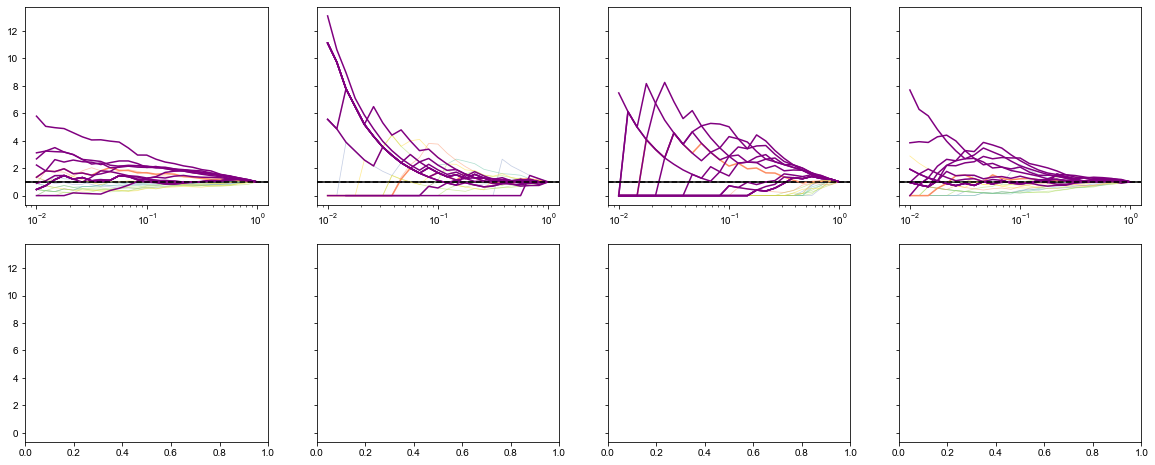

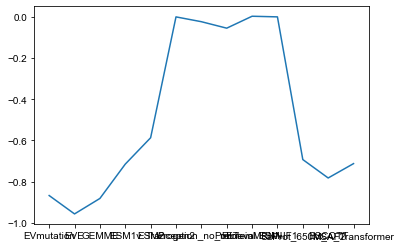

In [193]:
alphas = pd.DataFrame(all_alpha_dicts)
alphas['mean_alpha'] = alphas.mean(axis=1)
mean_alpha = alphas['mean_alpha']
plt.plot(mean_alpha)

/var/folders/23/02r51lhs1890z43wddtd5qpw0000gr/T/ipykernel_51221/1693609252.py:37: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot([x_pos-mean_line_width/2, x_pos+mean_line_width/2], [dc_mean[i], dc_mean[i]], c='k', lw=3, zorder=10)


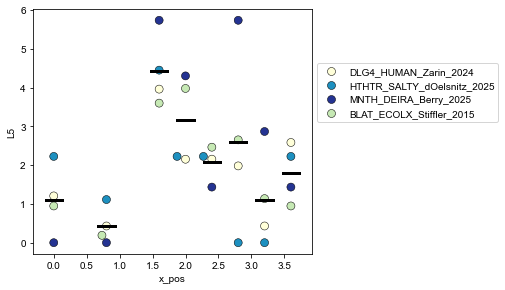

In [ ]:
plt.figure(figsize=(5.0, 4.5))

StudioSwarmplot(data, model_classification_new, value_name="L5", dataset_list=dataset_list)

plt.savefig("/Users/sam/Dropbox (Harvard University)/SpecificityStudio/Figures/Figure 3/design_l5_comparison_v3.pdf", bbox_inches='tight')

In [199]:
data

model,"Ensemble (Site_independent, ESM1v)","Ensemble (Site_independent, ESM2)","Ensemble (Site_independent, SaProt_650M_AF2)","Ensemble (Site_independent, GEMME)","Ensemble (Site_independent, EVmutation)","Ensemble (Site_independent, ESCOTT)","Ensemble (Site_independent, EVE)",Site_independent,ESM1v,protein
L5_DLG4_HUMAN_Zarin_2024,3.95843,2.151321,1.979215,2.152535,2.583042,1.722028,0.430507,1.20542,0.430264,L5_DLG4_HUMAN_Zarin_2024
L5_HTHTR_SALTY_dOelsnitz_2025,4.447619,2.22381,0.0,2.22381,2.22381,2.22381,0.0,2.22381,1.111905,L5_HTHTR_SALTY_dOelsnitz_2025
L5_MNTH_DEIRA_Berry_2025,5.732523,4.299392,5.732523,1.433131,1.433131,0.0,2.866261,0.0,0.0,L5_MNTH_DEIRA_Berry_2025
L5_BLAT_ECOLX_Stiffler_2015,3.597143,3.97579,2.650527,2.461203,0.946617,2.27188,1.13594,0.946617,0.189323,L5_BLAT_ECOLX_Stiffler_2015
mean_L5,4.433929,3.162578,2.590566,2.06767,1.79665,1.554429,1.108177,1.093961,0.432873,mean_L5
model_2,ESM1v,ESM2,SaProt_650M_AF2,GEMME,EVmutation,ESCOTT,EVE,NaN,NaN,model_2
mean_alpha,-0.715082,-0.586944,-0.692903,-0.881758,-0.867632,-0.782324,-0.956861,-1.0,-1.0,mean_alpha


In [208]:
model_names

['Site_independent',
 'EVmutation',
 'EVE',
 'GEMME',
 'ESM1v',
 'ESM2',
 'Progen2',
 'Tranception_no_retrieval',
 'MSA_Transformer',
 'PoET',
 'ProteinMPNN',
 'ESM-IF1',
 'SaProt_650M_AF2',
 'ESCOTT']

/var/folders/23/02r51lhs1890z43wddtd5qpw0000gr/T/ipykernel_51221/3615324998.py:28: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot([x_pos-mean_line_width/2, x_pos+mean_line_width/2], [dc_mean[i], dc_mean[i]], c='k', lw=3, zorder=10)


KeyError: 'EVmutation'

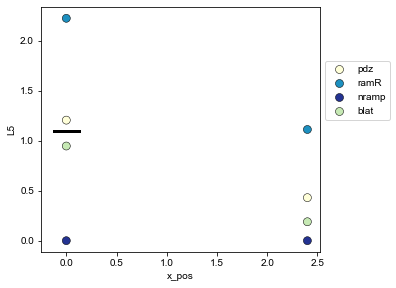

In [206]:
plt.figure(figsize=(5.0, 4.5))

data = class_1_l5s.loc[['Site_independent' in i or 'ESM1v' in i or i=='mean_L5' for i in class_1_l5s.index]].sort_values('mean_L5', ascending=False)
model_2 = [i.split(', ')[1].replace(')', '') if 'Ensemble' in i else np.nan for i in data.index]

data['model_2'] = model_2
data['mean_alpha'] = [mean_alpha[i] if i in mean_alpha else -1 for i in model_2]
data = data.loc[data.mean_alpha.abs()>0.1].T

data_c = data.iloc[:4].copy()
data_c['protein']=['pdz', 'ramR', 'nramp', 'blat']

data_long = data_c.melt(id_vars='protein', value_vars = [i for i in data.columns if i!='protein' and i!='mean'], var_name='model', value_name='L5')

model_classification_filt = {m:cat for m,cat in model_classification.items() if m in model_names and m!='ProteinMPNN'}
pos_dict = get_custom_coords(model_classification_filt, intra_gap=0.4, inter_gap=0.8)
data_long['x_pos'] = data_long['model'].map(pos_dict)

sns.swarmplot(data=data_long, hue='protein', y='L5', x='x_pos', palette=map_cmap_to_proteins(protein_color_map, cm.YlGnBu), edgecolor='k', linewidth=0.5, s=8, native_scale=True)
plt.legend(loc='upper left', bbox_to_anchor=(1, 0.8))

mean_line_width=0.25

dc_mean = pd.Series(data_c.values[:,:-2].mean(axis=0), index=data_c.columns[:-2])

for model,x_pos in pos_dict.items():
    i = data_c.columns.get_loc(model)
    plt.plot([x_pos-mean_line_width/2, x_pos+mean_line_width/2], [dc_mean[i], dc_mean[i]], c='k', lw=3, zorder=10)

plt.xticks(list(pos_dict.values()), order, rotation=90)
plt.ylabel("L5 score")

In [209]:
plt.figure(figsize=(5.0, 4.5))

sns.swarmplot(data=data_long, hue='protein', y='L5_score', x='x_pos', palette=map_cmap_to_proteins(protein_color_map, cm.YlGnBu), edgecolor='k', linewidth=0.5, s=8, native_scale=True)
plt.legend(loc='upper left', bbox_to_anchor=(1, 0.8))

mean_line_width=0.25

dc_mean = pd.Series(data_c.values[:,:-2].mean(axis=0), index=data_c.columns[:-2])

for model,x_pos in pos_dict.items():
    i = data_c.columns.get_loc(model)
    plt.plot([x_pos-mean_line_width/2, x_pos+mean_line_width/2], [dc_mean[i], dc_mean[i]], c='k', lw=3, zorder=10)

plt.xticks(list(pos_dict.values()), order, rotation=90)
plt.ylabel("L5 score")

ValueError: Could not interpret value `L5_score` for `y`. An entry with this name does not appear in `data`.

<Figure size 360x324 with 0 Axes>

model
Ensemble (Site_independent, ESM1v)                       1
Ensemble (Site_independent, ESM2)                        1
Ensemble (Site_independent, SaProt_650M_AF2)             1
Ensemble (Site_independent, GEMME)                       1
Ensemble (Site_independent, EVmutation)                  1
Ensemble (Site_independent, ESCOTT)                      1
Ensemble (Site_independent, ESM-IF1)                     1
Ensemble (Site_independent, EVE)                         1
Site_independent                                         1
Ensemble (Site_independent, Progen2)                     1
Ensemble (Site_independent, PoET)                        1
Ensemble (Site_independent, ProteinMPNN)                 1
Ensemble (Site_independent, Tranception_no_retrieval)    1
ESM1v                                                    1
Name: mean_alpha, dtype: int64


(-0.25, 7.0)

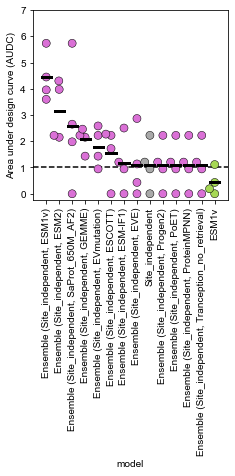

In [ ]:
data = class_1_l5s.loc[['Site_independent' in i or 'ESM1v' in i or i=='mean_L5' for i in class_1_l5s.index]].sort_values('mean_L5', ascending=False)
model_2 = [i.split(', ')[1].replace(')', '') if 'Ensemble' in i else np.nan for i in data.index]
data['model_2'] = model_2
data['mean_alpha'] = [mean_alpha[i] if i in mean_alpha else -1 for i in model_2]
print(data.mean_alpha.abs())
data = data.loc[data.mean_alpha.abs()>0.1].T

plt.figure(figsize=(3.5,3.5))
sns.swarmplot(data=data.drop('mean_L5').drop('model_2').drop('mean_alpha'), s=8,
              palette=[color_key[model_classification[x]] if x in model_classification else 'orchid' for x in data.columns],
              edgecolor='k', linewidth=0.5)
plt.axhline(1, c='k', ls='dashed')

colors = [color_key[model_classification[x]] if x in model_classification else 'orchid' for x in data.columns]

d = data.drop('mean_L5').drop('model_2').drop('mean_alpha')

for i in range(data.shape[1]):
    plt.plot([i-0.35, i+0.35], [d.values[:,i].mean(), d.values[:,i].mean()], c='k', lw=3, zorder=10)

plt.xticks(rotation=90);
plt.ylabel("Area under design curve (AUDC)")
#plt.yscale('log')
plt.ylim(-0.25, 7)


In [69]:
class_1_l5s

,L5_DLG4_HUMAN_Zarin_2024,L5_HTHTR_SALTY_dOelsnitz_2025,L5_MNTH_DEIRA_Berry_2025,L5_PHO4_YEAST_Aditham_2021,L5_BLAT_ECOLX_Stiffler_2015,mean_L5
model,,,,,,
Site_independent,1.205420,2.223810,0.000000,4.017857,0.946617,1.678741
EVmutation,0.602710,2.223810,0.000000,1.097436,1.135940,1.011979
EVE,0.688811,0.000000,0.000000,1.910204,0.189323,0.557668
GEMME,1.033217,0.000000,0.000000,0.000000,0.189323,0.244508
ESM1v,0.430264,1.111905,0.000000,1.646154,0.189323,0.675529
ESM2,0.258159,3.335714,0.000000,1.097436,0.189323,0.976126
Progen2,0.602710,0.000000,0.000000,2.743590,0.757293,0.820719
Tranception_no_retrieval,0.430264,0.000000,0.000000,2.194872,0.946617,0.714351
MSA_Transformer,0.688423,NaN,0.000000,1.646154,0.189323,0.630975


(-0.25, 7.0)

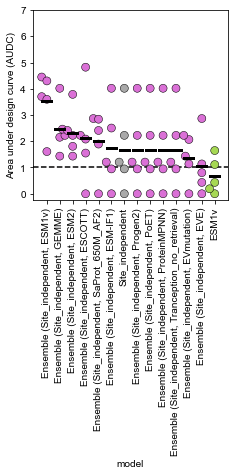

In [68]:

plt.figure(figsize=(3.5,3.5))
sns.swarmplot(data=data.drop('mean_L5').drop('model_2').drop('mean_alpha'), s=8,
              palette=[color_key[model_classification[x]] if x in model_classification else 'orchid' for x in data.columns],
              edgecolor='k', linewidth=0.5)
plt.axhline(1, c='k', ls='dashed')

colors = [color_key[model_classification[x]] if x in model_classification else 'orchid' for x in data.columns]

d = data.drop('mean_L5').drop('model_2').drop('mean_alpha')

for i in range(data.shape[1]):
    plt.plot([i-0.35, i+0.35], [d.values[:,i].mean(), d.values[:,i].mean()], c='k', lw=3, zorder=10)

plt.xticks(rotation=90);
plt.ylabel("Area under design curve (AUDC)")
#plt.yscale('log')
plt.ylim(-0.25, 7)